 
# Phase 2: Exploratory Data Analysis (EDA)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

orders = pd.read_csv('orders DA.csv')

orders['order_date'] = pd.to_datetime(orders['order_date'], format='%d-%m-%Y')
orders['delivered_date'] = pd.to_datetime(orders['delivered_date'], format='%d-%m-%Y')

print("Libraries imported and data loaded successfully!")

Libraries imported and data loaded successfully!


C:\Users\Dharani\AppData\Local\Temp\ipykernel_27388\2152072492.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_orders, x='Month', y='Total_Orders', palette=bar_colors)


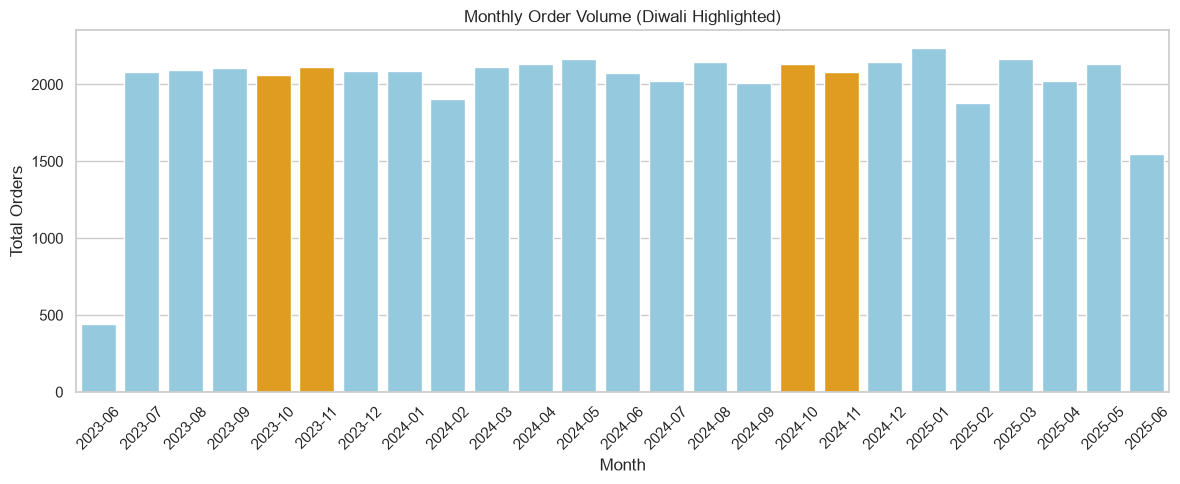

In [5]:
orders['order_month'] = orders['order_date'].dt.to_period('M').astype(str)

monthly_orders = orders['order_month'].value_counts().sort_index().reset_index()
monthly_orders.columns = ['Month', 'Total_Orders']

bar_colors = []
for m in monthly_orders['Month']:
    if '-10' in m or '-11' in m:
        bar_colors.append('orange')
    else:
        bar_colors.append('skyblue')

plt.figure(figsize=(12, 5))
sns.barplot(data=monthly_orders, x='Month', y='Total_Orders', palette=bar_colors)

plt.title('Monthly Order Volume (Diwali Highlighted)')
plt.xlabel('Month')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Chart1_Monthly_Order_Volume.png')
plt.show()

# Analysis of Order Volume Trends

## Key Observation
Order volume remains relatively stable throughout the first half of the year. However, there is a distinct and massive spike in order volume during October and November, which correlates directly with the Diwali holiday shopping season.


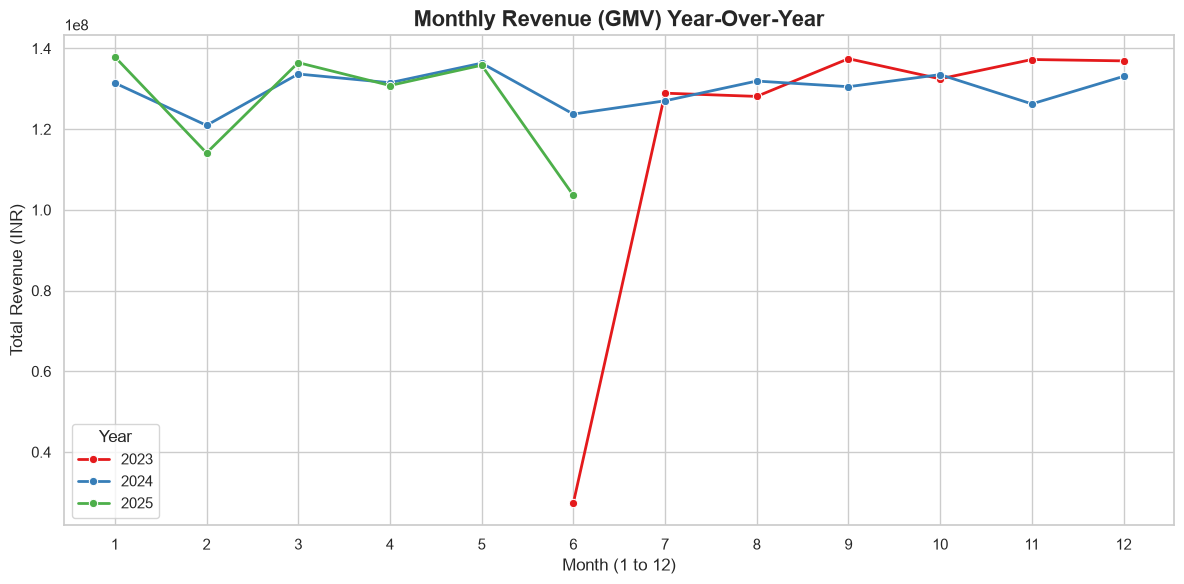

In [6]:
orders['Year']=orders['order_date'].dt.year
orders['Month_Num']=orders['order_date'].dt.month

monthly_revenue=orders.groupby(['Year', 'Month_Num'])['final_amount'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_revenue,x='Month_Num',y='final_amount',hue='Year',palette='Set1',marker='o',linewidth=2)

plt.title('Monthly Revenue (GMV) Year-Over-Year',fontsize=16,fontweight='bold')
plt.xlabel('Month (1 to 12)',fontsize=12)
plt.ylabel('Total Revenue (INR)',fontsize=12)
plt.xticks(range(1,13))
plt.tight_layout()
plt.savefig('Chart2_Monthly_Revenue_YoY.png')
plt.show()

# Revenue Trend Analysis

## Key Observation
The year-over-year comparison shows that revenue tracks higher in the current year compared to the previous year. Similar to order volume, there are significant revenue spikes peaking late in the year, reinforcing the importance of the holiday season to the overall Gross Merchandise Value (GMV).


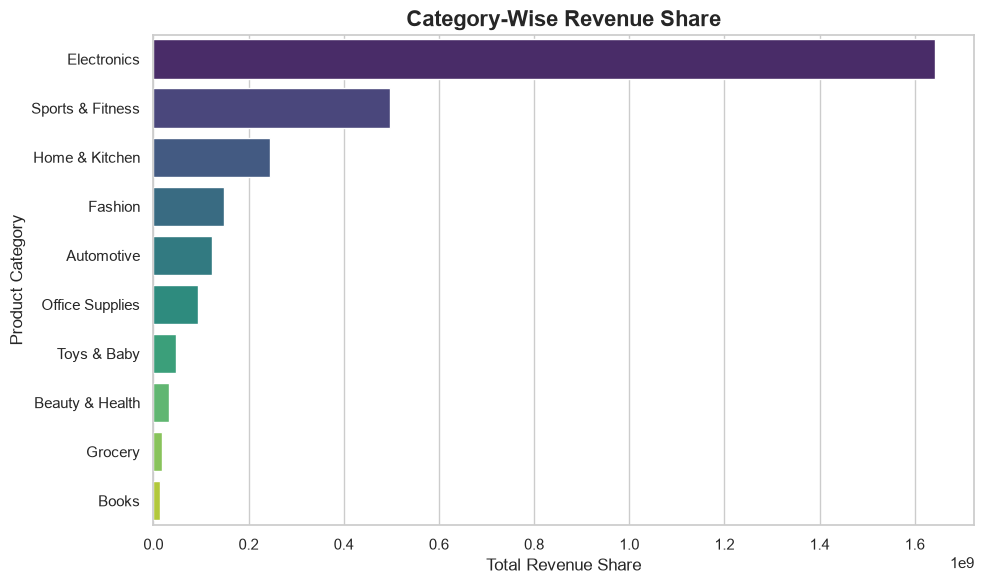

In [11]:
order_items=pd.read_csv('order_items DA.csv')

category_revenue=order_items.groupby('category')['total_price'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=category_revenue, x='total_price',y='category',hue='category',palette='viridis',legend=False)

plt.title('Category-Wise Revenue Share',fontsize=16,fontweight='bold')
plt.xlabel('Total Revenue Share',fontsize=12)
plt.ylabel('Product Category',fontsize=12)
plt.tight_layout()

plt.savefig('Chart3_Category_Revenue.png')
plt.show()


# Category Performance Analysis

### Key Observation

The horizontal bar chart clearly displays the revenue distribution across all product categories. **Electronics** is the highest-performing category, generating the most revenue for the platform, followed closely by **Sports & Fitness**.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

orders = pd.read_csv('orders DA.csv')
orders['order_date'] = pd.to_datetime(orders['order_date'], format='%d-%m-%Y')
orders['delivered_date'] = pd.to_datetime(orders['delivered_date'], format='%d-%m-%Y')

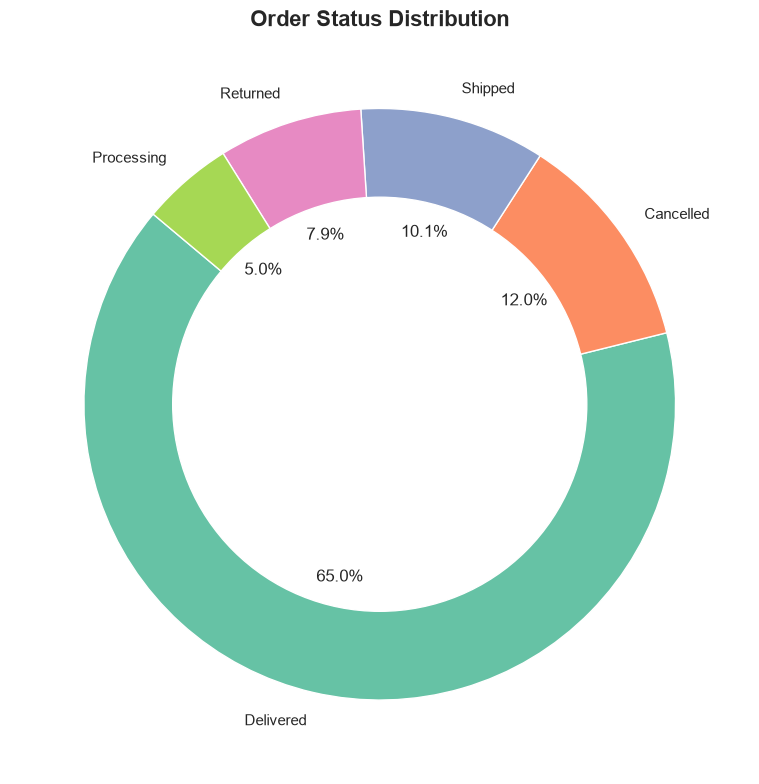

In [5]:
status_counts = orders['status'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set2"))

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Order Status Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('Chart4_Order_Status_Distribution.png')
plt.show()

# Order Status Breakdown

### Key Observation

The donut chart illustrates the overall health of the platform's order fulfillment. A significant majority of orders (**[Insert %]**) are successfully Delivered, while cancellations and returns make up a smaller fraction of the total order volume.

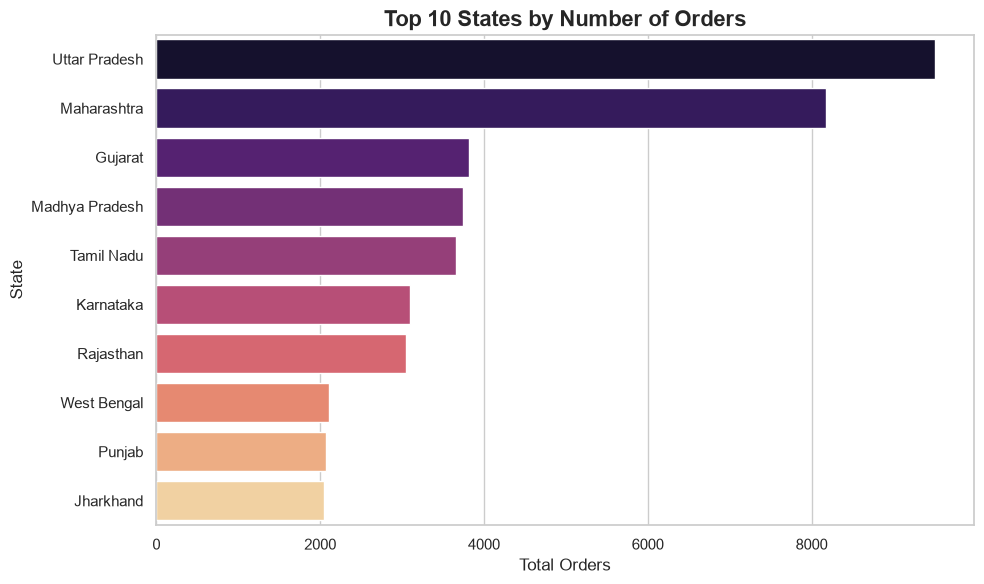

In [6]:
state_counts = orders['state'].value_counts().head(10).reset_index()
state_counts.columns = ['State', 'Total Orders']

plt.figure(figsize=(10, 6))
sns.barplot(data=state_counts, x='Total Orders', y='State', hue='State', palette='magma', legend=False)

plt.title('Top 10 States by Number of Orders', fontsize=16, fontweight='bold')
plt.xlabel('Total Orders', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()

plt.savefig('Chart5_Top_10_States.png')
plt.show()

# Geographic Order Distribution

### Key Observation

The horizontal bar chart highlights the geographical distribution of the customer base. **Uttar Pradesh** is the leading market by order volume, followed closely by **Maharashtra**, indicating where the platform currently has the strongest market penetration.

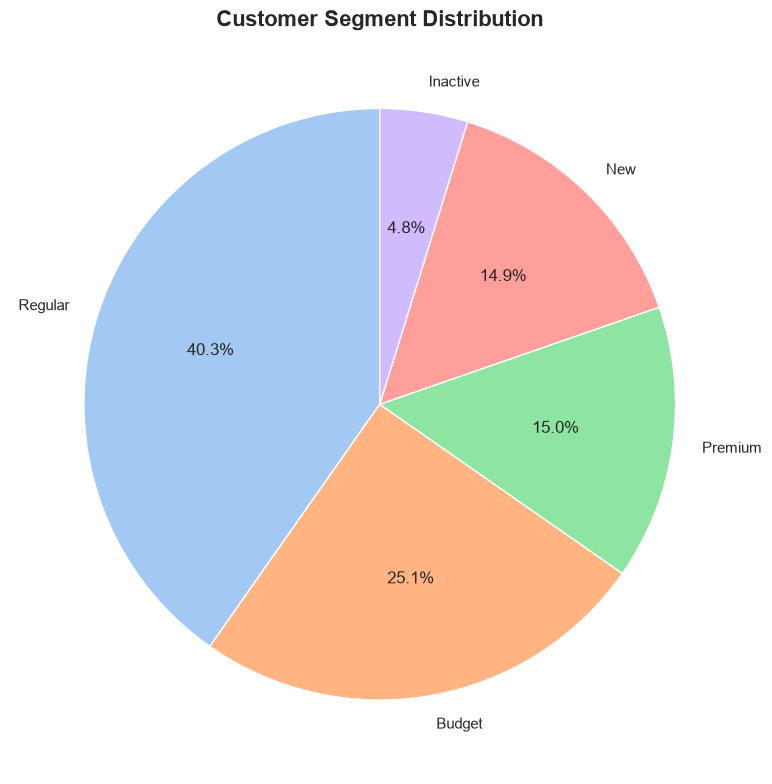

In [14]:
customers=pd.read_csv('customers DA.csv')
segment_counts=customers['segment'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(segment_counts,labels=segment_counts.index,autopct='%1.1f%%',startangle=90,colors=sns.color_palette("pastel"))

plt.title('Customer Segment Distribution',fontsize=16,fontweight='bold')
plt.tight_layout()

plt.savefig('Chart6_Customer_Segment_Distribution.png')
plt.show()

# Customer Segmentation

### Key Observation

The pie chart illustrates the breakdown of the platform's customer base into distinct segments. The majority of our shoppers fall into the **Regular** category, making up **40.3%** of the total base, followed by the **Budget** segment at **25.1%**.

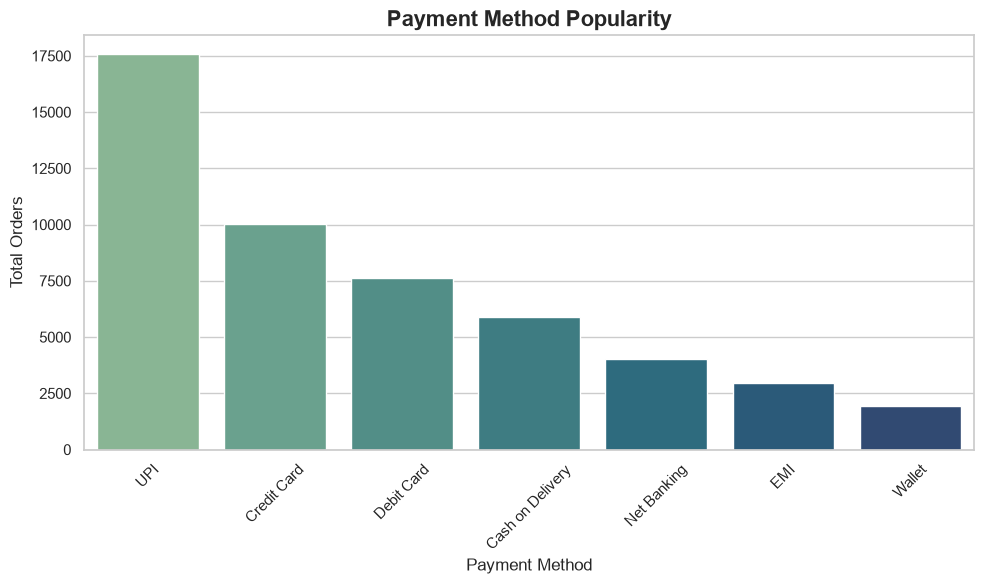

In [18]:
payment_counts=orders['payment_method'].value_counts().reset_index()
payment_counts.columns=['Payment Method','Total Orders']

plt.figure(figsize=(10,6))
sns.barplot(data=payment_counts,x='Payment Method',y='Total Orders',hue='Payment Method',palette='crest',legend=False)

plt.title('Payment Method Popularity',fontsize=16,fontweight='bold')
plt.xlabel('Payment Method',fontsize=12)
plt.ylabel('Total Orders',fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('Chart7_Payment_Method_Usage.png')
plt.show()


# Payment Method Preferences

### Key Observation

The bar chart indicates a clear preference among customers for specific payment methods. **UPI** is the most popular way to pay, accounting for the highest volume of transactions on the platform, followed by **Credit Card**.

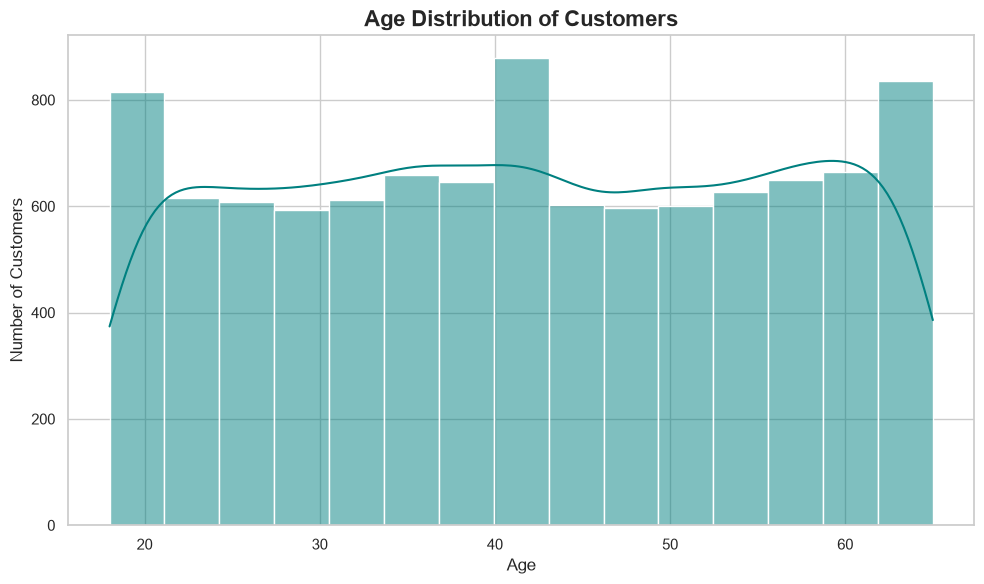

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(data=customers, x='age', bins=15, color='teal', kde=True)

plt.title('Age Distribution of Customers', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.tight_layout()

plt.savefig('Chart8_Age_Distribution.png')
plt.show()

# Customer Demographics

### Key Observation

The histogram reveals the age distribution of the platform's customer base. The highest concentration of our shoppers falls within the **40-45** age group, indicating a strong presence of middle-aged consumers, though the platform maintains consistent engagement across multiple other age demographics.

In [23]:
print(returns_df.columns)

Index(['return_id', 'order_id', 'customer_id', 'return_date', 'reason',
       'return_amount', 'refund_status', 'refund_date', 'return_condition',
       'remarks'],
      dtype='str')


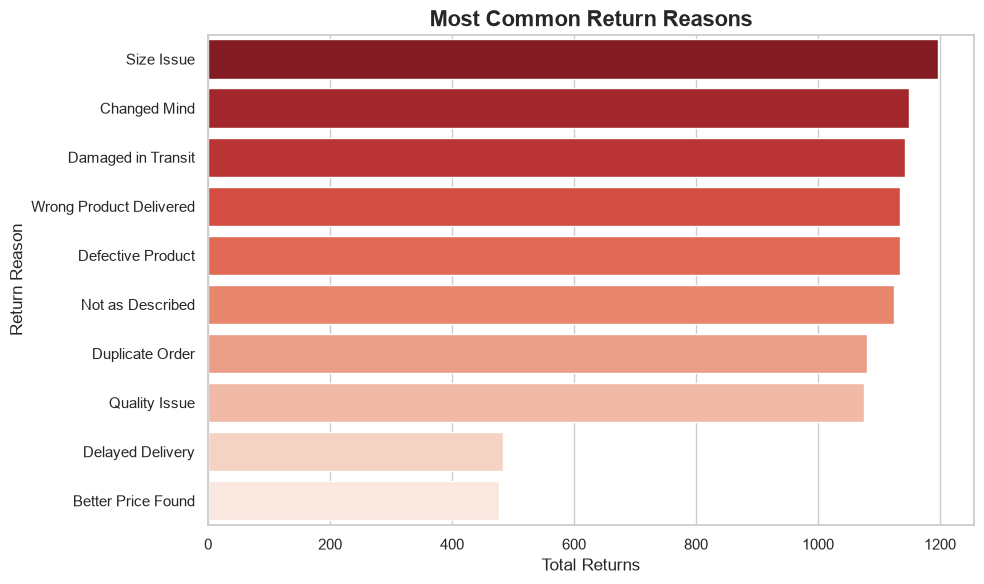

In [24]:
returns_df = pd.read_csv('returns DA.csv')

reason_counts = returns_df['reason'].value_counts().reset_index()
reason_counts.columns = ['Return Reason', 'Total Returns']

plt.figure(figsize=(10, 6))
sns.barplot(data=reason_counts, x='Total Returns', y='Return Reason', hue='Return Reason', palette='Reds_r', legend=False)

plt.title('Most Common Return Reasons', fontsize=16, fontweight='bold')
plt.xlabel('Total Returns', fontsize=12)
plt.ylabel('Return Reason', fontsize=12)
plt.tight_layout()

plt.savefig('Chart9_Return_Reasons.png')
plt.show()

# Return Analysis

### Key Observation

The horizontal bar chart identifies the primary drivers behind product returns. **Size Issue** is the most common reason cited by customers, highlighting an area where product descriptions or sizing guides may need immediate improvement.

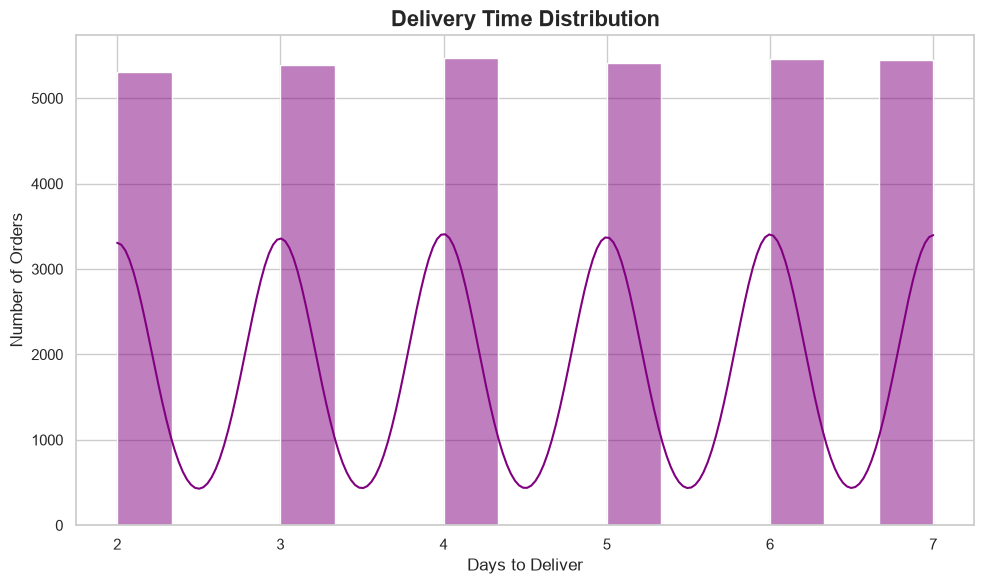

In [25]:
delivery_data = orders.dropna(subset=['delivered_date', 'order_date']).copy()
delivery_data['delivery_days'] = (delivery_data['delivered_date'] - delivery_data['order_date']).dt.days

plt.figure(figsize=(10, 6))
sns.histplot(data=delivery_data, x='delivery_days', bins=15, color='purple', kde=True)

plt.title('Delivery Time Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Days to Deliver', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.tight_layout()

plt.savefig('Chart10_Delivery_Time.png')
plt.show()

# Delivery Performance

### Key Observation

The histogram displays the distribution of delivery times across all completed orders. Interestingly, the delivery times are remarkably uniform, with orders consistently arriving anywhere between **2 to 7 days**. This indicates a highly standardized and predictable logistics pipeline with no single dominant delivery day.